In [16]:
from collections import Counter

import arabic_reshaper
import matplotlib.pyplot as plt
import pandas as pd

from parser import export_to_jsonl, extract_text_from_cupt
from typing import Any, cast
from plots import format_arabic_text

In [2]:
RAW_DATA_DIR = "data/raw/"
PROCESSED_DATA_DIR = "data/processed/"

In [3]:
data = extract_text_from_cupt(RAW_DATA_DIR + "train.cupt")

export_to_jsonl(data, PROCESSED_DATA_DIR + "train.jsonl")

data_df = pd.read_json(PROCESSED_DATA_DIR + "train.jsonl", lines=True)
data_df.head()

,sentence,mwes
0,ايران تعلن عن اختبار جديد ناجح لصاروخ شهاب 3,"[{'type': 'LVC.full', 'tokens': [{'text': 'تعل..."
1,وأكد النواب أن إجراء مفاوضات مع إسرائيل لتصدير...,"[{'type': 'LVC.full', 'tokens': [{'text': 'إجر..."
2,القاهرة 3 مايو,[]
3,تضم ليبيا ومصر ونيجيريا و التشاد,[]
4,وقال إن كمية التعاقد تبلغ 35 ألف متر مربع.,[]


total number of sentences 6091
sentences with mwe 2570


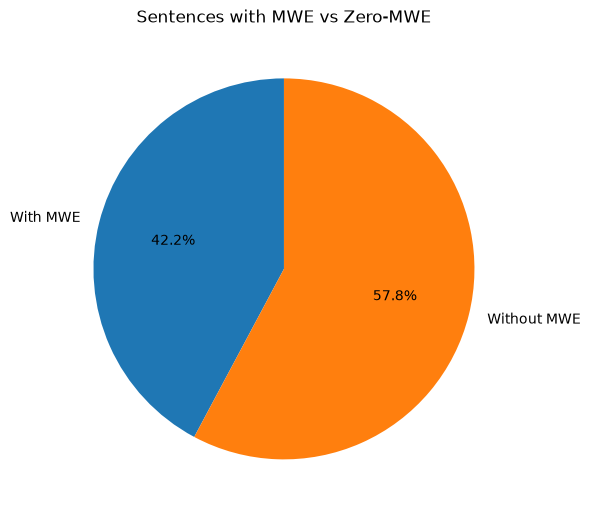

In [4]:
# sentences with at least one mwe
mwe_sentences_df = data_df[data_df["mwes"].apply(len) > 0]

print(f"total number of sentences {len(data_df)}")
print(f"sentences with mwe {len(mwe_sentences_df)}")

# pie plot of sentences with mwe vs zero-mwe
mwe_count = len(mwe_sentences_df)
zero_mwe_count = len(data_df) - mwe_count
pie_data = pd.Series(
    [mwe_count, zero_mwe_count],
    index=["With MWE", "Without MWE"],
)
fig, ax = plt.subplots(figsize=(6, 6))
pie_data.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ax=ax,
)
ax.set_title("Sentences with MWE vs Zero-MWE")
plt.tight_layout()
plt.show()

In [5]:
total_mwes = data_df["mwes"].apply(len).sum()
print(f"total mwes: {total_mwes}")

total mwes: 3841


discontinuous mwes: 1606


Text(0.5, 1.0, 'Proportion of Discontinuous MWEs')

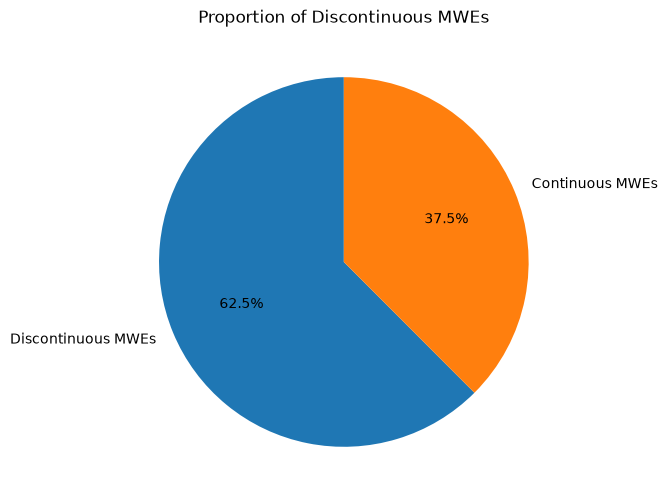

In [6]:
# check for discontinuity (interning tokens)
all_types = []
discontinuous_mwe_count = 0

# how many non-mwe words interrupting mwe
gap_lengths = []

# window size: distance between first and last word in the mwe
span_lengths = []

# mwe words counts
mwe_word_counts = [] 

# most frequent lemmas
lemma_counts = Counter()

# most frequent verbs
verb_counts = Counter()

for mwes_list in data_df["mwes"]:
    for mwe in mwes_list:
        mwe_word_counts.append(len(mwe["tokens"]))

        for token in mwe["tokens"]:
            lemma_counts[token["lemma"]] += 1
            if token["pos"] == "VERB":
                verb_counts[token["lemma"]] += 1
        
        all_types.append(mwe["type"])
        indices = sorted([int(token["index"]) for token in mwe["tokens"]])

        if len(indices) > 1 and indices[-1] - indices[0] + 1 > len(indices):
            discontinuous_mwe_count += 1

        if (len(indices)) > 1:
            span = indices[-1] - indices[0]
            gap = span - len(indices) + 1

            # if continuous mwe
            if gap > 0:
                gap_lengths.append(gap)
                span_lengths.append(span)

print(f"discontinuous mwes: {discontinuous_mwe_count}")

continuous_mwe_count = len(mwe_sentences_df) - discontinuous_mwe_count

continuity_data = pd.Series(
    [discontinuous_mwe_count, continuous_mwe_count],
    index=["Discontinuous MWEs", "Continuous MWEs"],
)

continuity_plt = continuity_data.plot(
    kind="pie", autopct="%1.1f%%", figsize=(6, 6), startangle=90
)
continuity_plt.set_title("Proportion of Discontinuous MWEs")

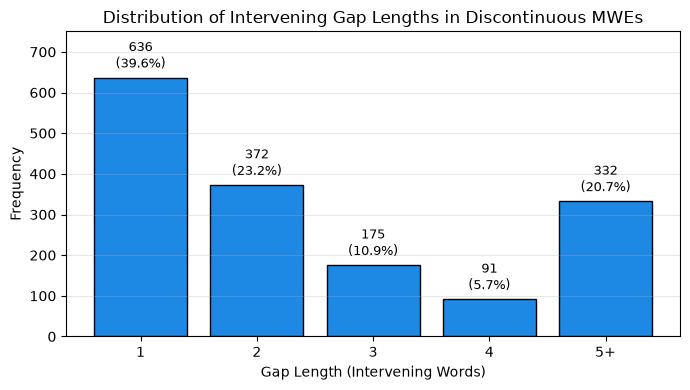

In [7]:
# plot the gap length via interval plots (5 intervals)
gap_series = pd.Series(gap_lengths)
gap_binned = gap_series.apply(lambda g: str(g) if g < 5 else "5+").value_counts()
gap_binned = gap_binned.reindex(["1", "2", "3", "4", "5+"], fill_value=0)
gap_pct = (gap_binned / gap_binned.sum()) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(gap_binned.index, gap_binned.values, color="#1E88E5", edgecolor="black")

# Add percentage and count labels above bars
for bar, pct in zip(bars, gap_pct):
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 15,
        f"{yval}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Distribution of Intervening Gap Lengths in Discontinuous MWEs")
ax.set_xlabel("Gap Length (Intervening Words)")
ax.set_ylabel("Frequency")
ax.set_ylim(0, max(gap_binned.values) * 1.18)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Gap statistics
gap_stats = pd.Series(gap_lengths).describe()

print(f"Min gap:    {gap_stats['min']:.0f}")
print(f"Median gap: {gap_stats['50%']:.0f}")
print(f"Avg gap:    {gap_stats['mean']:.2f}")
print(f"Max gap:    {gap_stats['max']:.0f}")


Min gap:    1
Median gap: 2
Avg gap:    3.17
Max gap:    32


In [9]:
# mwe type distribution
types_count = pd.Series(all_types).value_counts()
types_count

LVC.full     2178
VID           955
IAV           468
LVC.cause     236
MVC             4
Name: count, dtype: int64

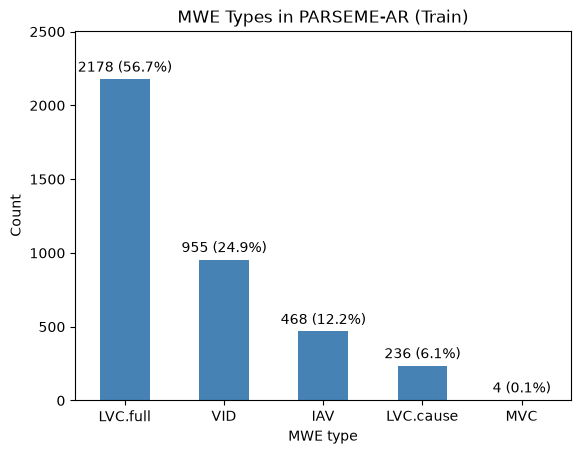

In [10]:
# plot the type distribution
types_pct = (types_count / types_count.sum()) * 100

type_distribution_plt = types_count.plot(
    kind="bar", title="MWE Types in PARSEME-AR (Train)", color="steelblue", rot=0
)
type_distribution_plt.set_xlabel("MWE type")
type_distribution_plt.set_ylabel("Count")

# Add labels and give room at the top
labels = [f"{c} ({p:.1f}%)" for c, p in zip(types_count, types_pct)]
type_distribution_plt.bar_label(type_distribution_plt.containers[0], labels=labels, padding=3)
type_distribution_plt.margins(y=0.15)


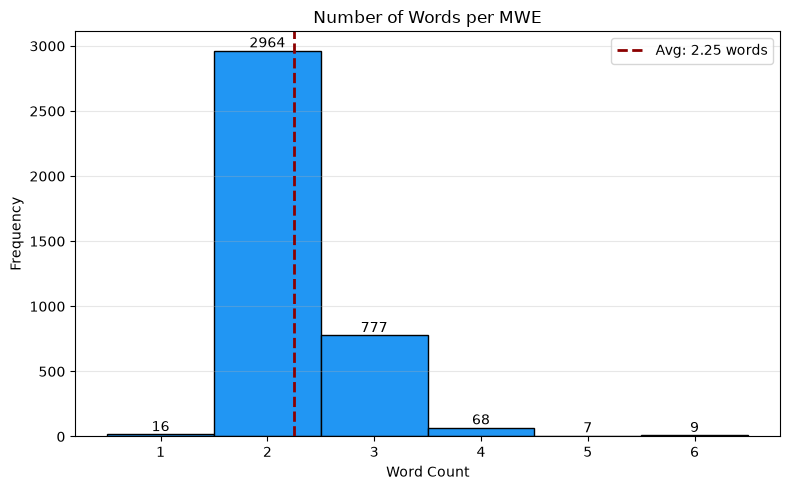

In [11]:
# Span plot (mwe length)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    mwe_word_counts,
    bins=range(min(mwe_word_counts), max(mwe_word_counts) + 2),
    color="#2196F3",
    edgecolor="black",
    align="left",
)

avg = sum(mwe_word_counts) / len(mwe_word_counts)
ax.axvline(
    avg, color="darkred", linestyle="--", linewidth=2, label=f"Avg: {avg:.2f} words"
)

ax.bar_label(ax.containers[0])
ax.set_title("Number of Words per MWE")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.set_xticks(range(min(mwe_word_counts), max(mwe_word_counts) + 1))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from plots import format_arabic_text

# top 20 most frequent lemmas
top_lemmas = lemma_counts.most_common(20)

labels_raw, values = zip(*top_lemmas)
labels = [format_arabic_text(l) for l in labels_raw]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), values, color="#2196F3", edgecolor="black")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontfamily="Arial Unicode MS", fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Frequent Lemmas in MWEs")
ax.bar_label(ax.containers[0], padding=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# top 20 frequent verb lemmas
top_verbs = verb_counts.most_common(20)

labels_raw, values = zip(*top_verbs)
labels = [format_arabic_text(l) for l in labels_raw]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), values, color="#2196F3", edgecolor="black")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontfamily="Arial Unicode MS", fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Frequent Verbs in MWEs")
ax.bar_label(ax.containers[0], padding=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


average number of MWEs per sentence: 0.63
max MWEs in a single sentence: 9
median MWEs per sentence: 0.0


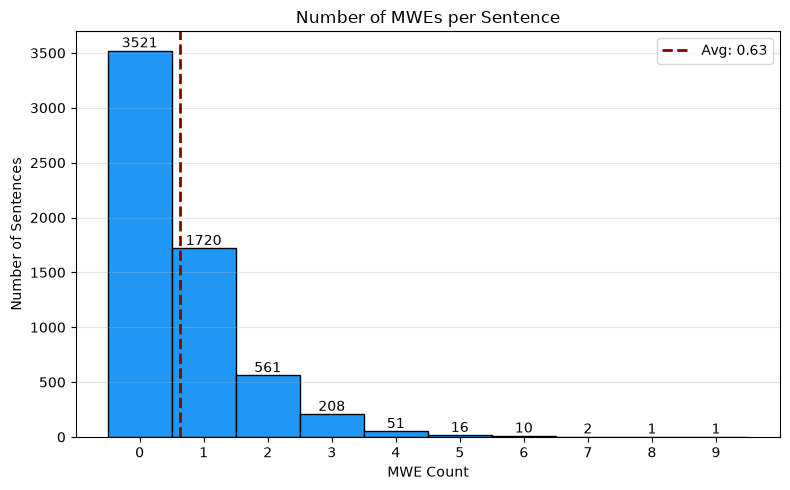

In [14]:
# count MWEs in each sentence and show the average
data_df["mwe_count"] = data_df["mwes"].apply(len)

avg_mwe = data_df["mwe_count"].mean()
print(f"average number of MWEs per sentence: {avg_mwe:.2f}")
print(f"max MWEs in a single sentence: {data_df['mwe_count'].max()}")
print(f"median MWEs per sentence: {data_df['mwe_count'].median()}")

# plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    data_df["mwe_count"],
    bins=range(0, data_df["mwe_count"].max() + 2),
    color="#2196F3",
    edgecolor="black",
    align="left",
)
ax.axvline(
    avg_mwe, color="darkred", linestyle="--", linewidth=2, label=f"Avg: {avg_mwe:.2f}"
)
ax.bar_label(ax.containers[0])
ax.set_title("Number of MWEs per Sentence")
ax.set_xlabel("MWE Count")
ax.set_ylabel("Number of Sentences")
ax.set_xticks(range(0, data_df["mwe_count"].max() + 1))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()